In [9]:
import pandas as pd

sentiment_df = pd.read_csv("../data/fear_greed_index.csv")
trades_df    = pd.read_csv("../data/historical_data.csv")

# quick look at both datasets
for name, df in [("SENTIMENT", sentiment_df), ("TRADES", trades_df)]:
    print(f"\n\n--- {name} ---")
    print("\nShape:", df.shape)
    print(df.dtypes)
    print(df.head(3))
    print("\nNulls:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())



--- SENTIMENT ---

Shape: (2644, 4)
timestamp          int64
value              int64
classification    object
date              object
dtype: object
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

Nulls:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0


--- TRADES ---

Shape: (211224, 16)
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object
                                      A

In [10]:
# fix date columns in both datasets
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

trades_df['date'] = pd.to_datetime(
    trades_df['Timestamp IST'], format='%d-%m-%Y %H:%M', dayfirst=True
).dt.normalize()

# quick sanity checks
print("Sentiment:", sentiment_df['date'].min(), "→", sentiment_df['date'].max())
print(sentiment_df['classification'].value_counts())

print("\nTrades:", trades_df['date'].min(), "→", trades_df['date'].max())
print(trades_df['Coin'].value_counts().head(10))
print(trades_df['Direction'].value_counts())
print("Non-zero PnL trades:", (trades_df['Closed PnL'] != 0).sum())

Sentiment: 2018-02-01 00:00:00 → 2025-05-02 00:00:00
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

Trades: 2023-05-01 00:00:00 → 2025-05-01 00:00:00
Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64
Non-zero PnL trades: 104408


In [11]:
# filter sentiment to overlapping date range
sentiment_df = sentiment_df[sentiment_df['date'] >= '2023-05-01'].copy()

# keep only core trade directions, remove liquidations/dust/settlements
valid_directions = ['Open Long', 'Close Long', 'Open Short', 'Close Short']
trades_clean  = trades_df[trades_df['Direction'].isin(valid_directions)].copy()
closed_trades = trades_clean[trades_clean['Closed PnL'] != 0].copy()

# collapse 5 sentiment classes to 3
sentiment_map = {
    'Extreme Fear': 'Fear', 'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed', 'Extreme Greed': 'Greed'
}
sentiment_df['sentiment'] = sentiment_df['classification'].map(sentiment_map)

print(f"Sentiment days: {len(sentiment_df)}")
print(f"Clean trades: {len(trades_clean)} | Closed trades: {len(closed_trades)}")
print(sentiment_df['sentiment'].value_counts())
print(closed_trades['Closed PnL'].describe())

closed_trades.to_csv("../charts/table_00_closed_trades.csv", index=False)
print("✅ table_00_closed_trades.csv saved")

Sentiment days: 732
Clean trades: 174327 | Closed trades: 84626
sentiment
Greed      411
Neutral    177
Fear       144
Name: count, dtype: int64
count     84626.000000
mean         86.648660
std        1310.645331
min     -117990.104100
25%           0.433558
50%           5.900628
75%          37.044806
max      135329.090100
Name: Closed PnL, dtype: float64
✅ table_00_closed_trades.csv saved


In [12]:
# daily aggregates per trader
def win_rate(pnl_series):
    return (pnl_series > 0).sum() / len(pnl_series)

daily_trader = closed_trades.groupby(['Account', 'date']).agg(
    daily_pnl      = ('Closed PnL', 'sum'),       # daily PnL per trader
    trade_count    = ('Closed PnL', 'count'),      # number of trades per day
    win_rate       = ('Closed PnL', win_rate),     # win rate
    avg_trade_size = ('Size USD', 'mean'),         # average trade size
    total_volume   = ('Size USD', 'sum')
).reset_index()

# long/short ratio per trader per day
direction_counts = trades_clean[trades_clean['Direction'].isin(['Open Long','Open Short'])]\
    .groupby(['Account', 'date', 'Direction']).size().unstack(fill_value=0).reset_index()

if 'Open Long' not in direction_counts.columns:
    direction_counts['Open Long'] = 0
if 'Open Short' not in direction_counts.columns:
    direction_counts['Open Short'] = 0

direction_counts = direction_counts.rename(columns={
    'Open Long': 'longs', 
    'Open Short': 'shorts'
})
direction_counts['long_short_ratio'] = (direction_counts['longs'] + 1) / (direction_counts['shorts'] + 1)

daily_trader = daily_trader.merge(
    direction_counts[['Account','date','longs','shorts','long_short_ratio']],
    on=['Account','date'], how='left'
)

# fill missing sides with 0, neutral ratio for traders with no opens that day
daily_trader['longs']            = daily_trader['longs'].fillna(0)
daily_trader['shorts']           = daily_trader['shorts'].fillna(0)
daily_trader['long_short_ratio'] = daily_trader['long_short_ratio'].fillna(1)

# leverage distribution proxy — no explicit leverage column, using trade size buckets
daily_trader['leverage_proxy'] = pd.cut(
    daily_trader['avg_trade_size'],
    bins=[0, 1710, 4856, float('inf')],
    labels=['Low', 'Medium', 'High']
)

# loss day flag as drawdown proxy
daily_trader['is_loss_day'] = (daily_trader['daily_pnl'] < 0).astype(int)

# merge with sentiment
merged = daily_trader.merge(
    sentiment_df[['date','classification','sentiment']],
    on='date', how='inner'
)

print("Merged shape:", merged.shape)
print("\nKey metrics sample:")
print(merged[['Account','date','daily_pnl','trade_count','win_rate',
              'avg_trade_size','long_short_ratio','leverage_proxy','sentiment']].head(3))

print("\nLeverage proxy distribution:")
print(daily_trader['leverage_proxy'].value_counts())

# save metrics table
merged.to_csv("../charts/table_00_daily_trader_metrics.csv", index=False)
print("✅ table_00_daily_trader_metrics.csv saved")

Merged shape: (1491, 14)

Key metrics sample:
                                      Account       date  daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-22   -21227.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-26     1603.1   
2  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-28  -132271.0   

   trade_count  win_rate  avg_trade_size  long_short_ratio leverage_proxy  \
0           12       0.0    28186.666667            1.0000           High   
1           12       1.0    19350.834167            0.0625           High   
2           82       0.0    16058.536341            1.0000           High   

  sentiment  
0     Greed  
1     Greed  
2     Greed  

Leverage proxy distribution:
leverage_proxy
Low       704
High      502
Medium    286
Name: count, dtype: int64
✅ table_00_daily_trader_metrics.csv saved


           median_pnl  mean_pnl  avg_win_rate  loss_day_rate  total_trades  \
sentiment                                                                    
Fear           825.89   8151.85          0.87           0.13         35830   
Neutral        588.93   4329.39          0.84           0.14         15834   
Greed          540.06   2730.86          0.84           0.12         32956   

           avg_trades_day  
sentiment                  
Fear                68.90  
Neutral             63.34  
Greed               45.71  
✅ table_01_performance_by_sentiment.csv saved


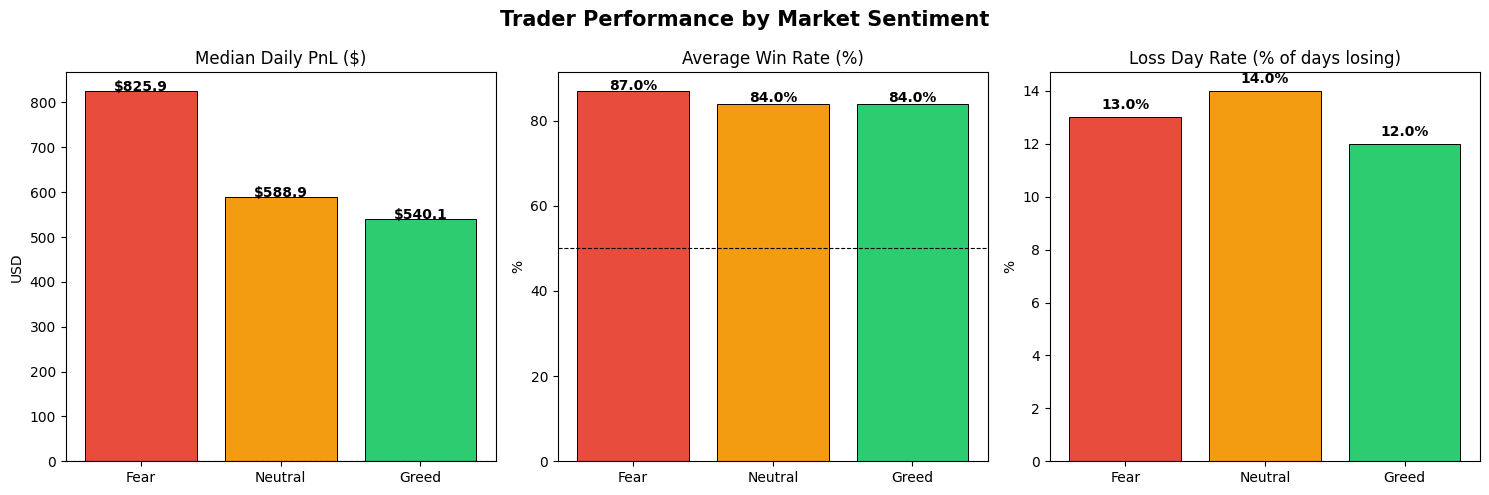

✅ 01_performance_by_sentiment.png saved


In [13]:
# PART B — Q1: Performance by Sentiment

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs("../charts", exist_ok=True)

# performance stats by sentiment
perf_by_sentiment = merged.groupby('sentiment').agg(
    median_pnl     = ('daily_pnl',   'median'),
    mean_pnl       = ('daily_pnl',   'mean'),
    avg_win_rate   = ('win_rate',    'mean'),
    loss_day_rate  = ('is_loss_day', 'mean'),
    total_trades   = ('trade_count', 'sum'),
    avg_trades_day = ('trade_count', 'mean'),
).round(2).reindex(['Fear', 'Neutral', 'Greed'])

print(perf_by_sentiment)

# save table
perf_by_sentiment.to_csv("../charts/table_01_performance_by_sentiment.csv")
print("✅ table_01_performance_by_sentiment.csv saved")

colors = {'Fear': '#e74c3c', 'Neutral': '#f39c12', 'Greed': '#2ecc71'}
sentiment_order = ['Fear', 'Neutral', 'Greed']
color_list = [colors[s] for s in sentiment_order]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Trader Performance by Market Sentiment', fontsize=15, fontweight='bold')

axes[0].bar(sentiment_order, perf_by_sentiment['median_pnl'],
            color=color_list, edgecolor='black', linewidth=0.7)
axes[0].set_title('Median Daily PnL ($)')
axes[0].set_ylabel('USD')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(perf_by_sentiment['median_pnl']):
    axes[0].text(i, v + 0.5, f'${v:.1f}', ha='center', fontweight='bold')

axes[1].bar(sentiment_order, perf_by_sentiment['avg_win_rate'] * 100,
            color=color_list, edgecolor='black', linewidth=0.7)
axes[1].set_title('Average Win Rate (%)')
axes[1].set_ylabel('%')
axes[1].axhline(50, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(perf_by_sentiment['avg_win_rate'] * 100):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

axes[2].bar(sentiment_order, perf_by_sentiment['loss_day_rate'] * 100,
            color=color_list, edgecolor='black', linewidth=0.7)
axes[2].set_title('Loss Day Rate (% of days losing)')
axes[2].set_ylabel('%')
for i, v in enumerate(perf_by_sentiment['loss_day_rate'] * 100):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/01_performance_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 01_performance_by_sentiment.png saved")

           avg_trade_size  avg_volume  avg_ls_ratio  avg_trades  \
sentiment                                                         
Fear              1801.62    52759.87           1.0        19.0   
Neutral           1936.32    66448.17           1.0        21.0   
Greed             2047.67    51285.26           1.0        21.0   

           pct_long_biased  pct_short_biased  
sentiment                                     
Fear                 48.27             35.96  
Neutral              44.80             39.20  
Greed                43.00             44.94  
✅ table_02_behavior_by_sentiment.csv saved


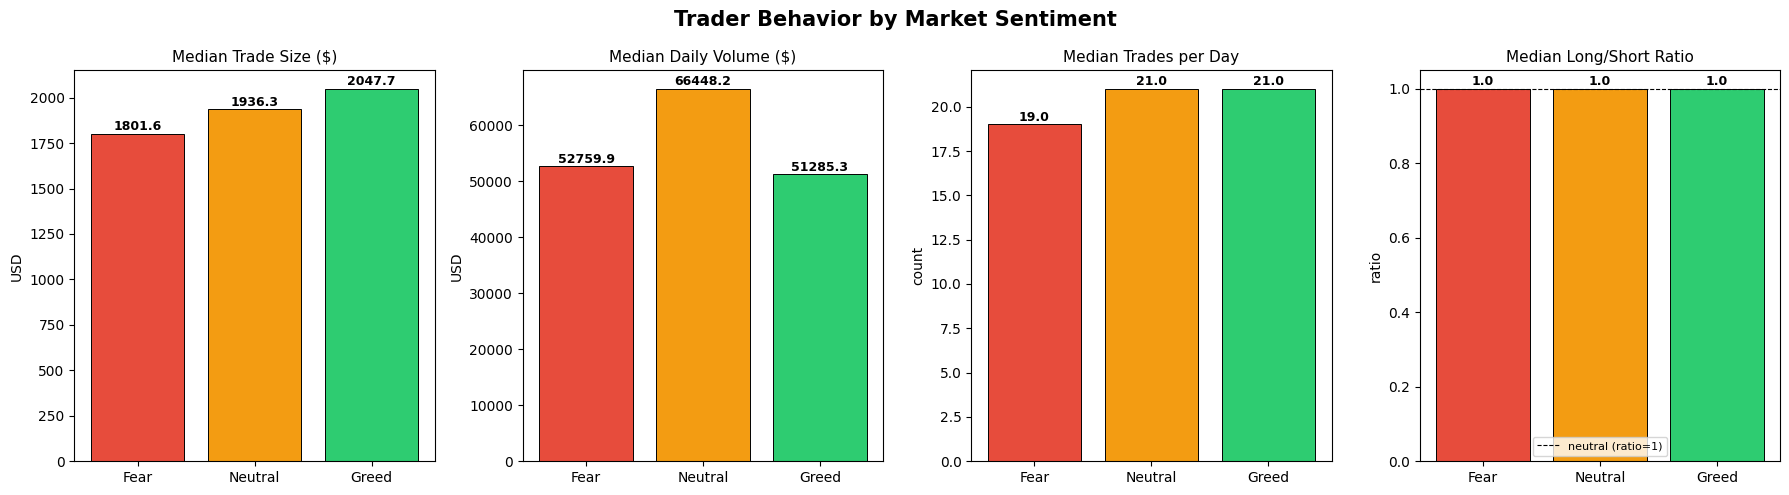

✅ 02_behavior_by_sentiment.png saved


In [14]:
# PART B — Q2: Behavioral Changes by Sentiment

# behavioral metrics by sentiment
behavior_by_sentiment = merged.groupby('sentiment').agg(
    avg_trade_size   = ('avg_trade_size',   'median'),
    avg_volume       = ('total_volume',     'median'),
    avg_ls_ratio     = ('long_short_ratio', 'median'),
    avg_trades       = ('trade_count',      'median'),
    pct_long_biased  = ('long_short_ratio', lambda x: (x > 1).mean() * 100),
    pct_short_biased = ('long_short_ratio', lambda x: (x < 1).mean() * 100),
).round(2).reindex(['Fear', 'Neutral', 'Greed'])

print(behavior_by_sentiment)

# save table
behavior_by_sentiment.to_csv("../charts/table_02_behavior_by_sentiment.csv")
print("✅ table_02_behavior_by_sentiment.csv saved")

colors = {'Fear': '#e74c3c', 'Neutral': '#f39c12', 'Greed': '#2ecc71'}
sentiment_order = ['Fear', 'Neutral', 'Greed']
color_list = [colors[s] for s in sentiment_order]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Trader Behavior by Market Sentiment', fontsize=15, fontweight='bold')

metrics = [
    ('avg_trade_size', 'Median Trade Size ($)',   'USD'),
    ('avg_volume',     'Median Daily Volume ($)', 'USD'),
    ('avg_trades',     'Median Trades per Day',   'count'),
    ('avg_ls_ratio',   'Median Long/Short Ratio', 'ratio'),
]

for ax, (col, title, ylabel) in zip(axes, metrics):
    vals = behavior_by_sentiment[col]
    ax.bar(sentiment_order, vals, color=color_list, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    for i, v in enumerate(vals):
        ax.text(i, v * 1.01, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)
    if col == 'avg_ls_ratio':
        ax.axhline(1, color='black', linewidth=0.8, linestyle='--', label='neutral (ratio=1)')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../charts/02_behavior_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 02_behavior_by_sentiment.png saved")

Total traders: 32
freq_segment
Infrequent    16
Frequent      16
Name: count, dtype: int64
size_segment
Large     11
Small     11
Medium    10
Name: count, dtype: int64
winner_segment
Consistent Winner    26
Struggling            3
Inconsistent          3
Name: count, dtype: int64
✅ table_04_trader_stats.csv saved

=== Segment 1: Frequent vs Infrequent ===
                        median_pnl  avg_win_rate  avg_size
freq_segment sentiment                                    
Frequent     Fear           798.19          0.88   1661.39
             Greed          526.45          0.84   1871.86
             Neutral        587.79          0.85   1651.77
Infrequent   Fear          2020.00          0.82   2675.83
             Greed         1538.94          0.82   3448.20
             Neutral       1076.78          0.80   7765.32
✅ table_05_freq_segment.csv saved

=== Segment 2: Winner Type ===
                             median_pnl  avg_win_rate  avg_size
winner_segment    sentiment            

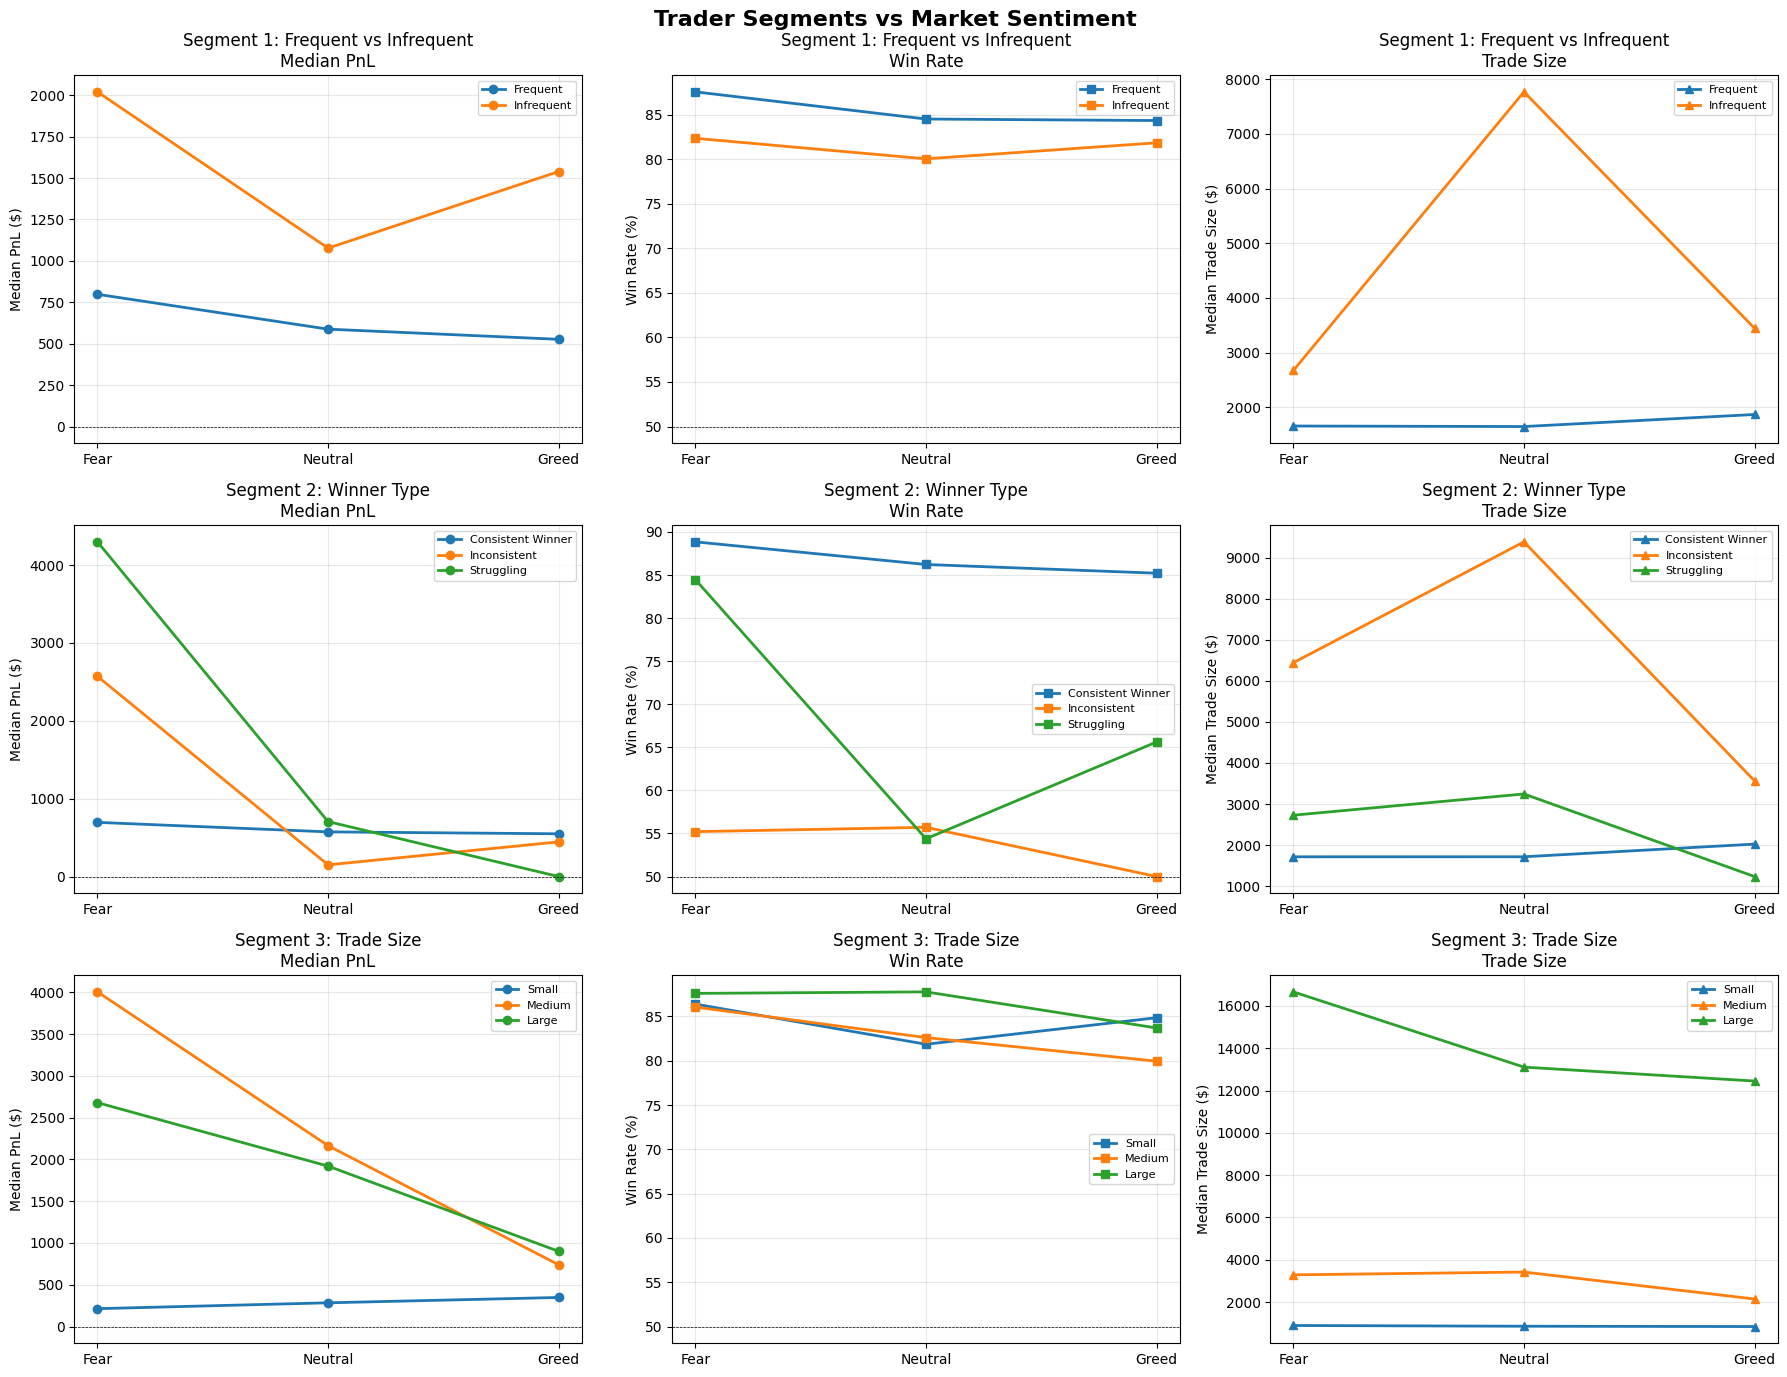

✅ 03_segments_vs_sentiment.png saved


In [16]:
# PART B — Q3: SEGMENTATION VISUALIZATION

# per-trader overall stats for segmentation
trader_stats = merged.groupby('Account').agg(
    total_pnl        = ('daily_pnl',       'sum'),
    median_pnl       = ('daily_pnl',       'median'),
    avg_win_rate     = ('win_rate',         'mean'),
    avg_trade_size   = ('avg_trade_size',   'median'),
    total_trade_days = ('date',             'count'),
    avg_trades_day   = ('trade_count',      'mean'),
    avg_ls_ratio     = ('long_short_ratio', 'median'),
    total_volume     = ('total_volume',     'sum'),
).reset_index()

# frequency segment
freq_median = trader_stats['total_trade_days'].median()
trader_stats['freq_segment'] = trader_stats['total_trade_days'].apply(
    lambda x: 'Frequent' if x > freq_median else 'Infrequent'
)

# size segment
size_33 = trader_stats['avg_trade_size'].quantile(0.33)
size_66 = trader_stats['avg_trade_size'].quantile(0.66)
trader_stats['size_segment'] = trader_stats['avg_trade_size'].apply(
    lambda x: 'Small' if x <= size_33 else ('Large' if x >= size_66 else 'Medium')
)

# winner segment
trader_stats['winner_segment'] = trader_stats.apply(
    lambda r: 'Consistent Winner' if (r['avg_win_rate'] >= 0.7 and r['total_pnl'] > 0)
              else ('Struggling'  if  r['total_pnl'] <= 0
              else 'Inconsistent'), axis=1
)

print("Total traders:", len(trader_stats))
print(trader_stats['freq_segment'].value_counts())
print(trader_stats['size_segment'].value_counts())
print(trader_stats['winner_segment'].value_counts())

# save
trader_stats.to_csv("../charts/table_04_trader_stats.csv", index=False)
print("✅ table_04_trader_stats.csv saved")

# attach segments to main df
merged = merged.merge(
    trader_stats[['Account','freq_segment','winner_segment','size_segment']],
    on='Account', how='left'
)

# segment summary tables + charts
segments = [
    ('freq_segment',   ['Frequent','Infrequent'],                        'Segment 1: Frequent vs Infrequent'),
    ('winner_segment', ['Consistent Winner','Inconsistent','Struggling'], 'Segment 2: Winner Type'),
    ('size_segment',   ['Small','Medium','Large'],                        'Segment 3: Trade Size'),
]

for seg_col, seg_vals, seg_title in segments:
    seg_table = merged.groupby([seg_col, 'sentiment']).agg(
        median_pnl   = ('daily_pnl',      'median'),
        avg_win_rate = ('win_rate',       'mean'),
        avg_size     = ('avg_trade_size', 'median')
    ).round(2)
    print(f"\n=== {seg_title} ===")
    print(seg_table)
    seg_table.to_csv(f"../charts/table_05_{seg_col}.csv")
    print(f"✅ table_05_{seg_col}.csv saved")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Trader Segments vs Market Sentiment', fontsize=16, fontweight='bold')

sentiment_order = ['Fear', 'Neutral', 'Greed']

for row, (seg_col, seg_vals, seg_title) in enumerate(segments):
    for seg_val in seg_vals:
        subset = merged[merged[seg_col] == seg_val]
        pnl  = subset.groupby('sentiment')['daily_pnl'].median().reindex(sentiment_order)
        wr   = subset.groupby('sentiment')['win_rate'].mean().reindex(sentiment_order) * 100
        size = subset.groupby('sentiment')['avg_trade_size'].median().reindex(sentiment_order)
        axes[row][0].plot(sentiment_order, pnl,  marker='o', label=seg_val, linewidth=2)
        axes[row][1].plot(sentiment_order, wr,   marker='s', label=seg_val, linewidth=2)
        axes[row][2].plot(sentiment_order, size, marker='^', label=seg_val, linewidth=2)

    for ax, title, ylabel in zip(axes[row],
        [f'{seg_title}\nMedian PnL', f'{seg_title}\nWin Rate', f'{seg_title}\nTrade Size'],
        ['Median PnL ($)', 'Win Rate (%)', 'Median Trade Size ($)']):
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    axes[row][0].axhline(0,  color='black', linewidth=0.5, linestyle='--')
    axes[row][1].axhline(50, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('../charts/03_segments_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 03_segments_vs_sentiment.png saved")

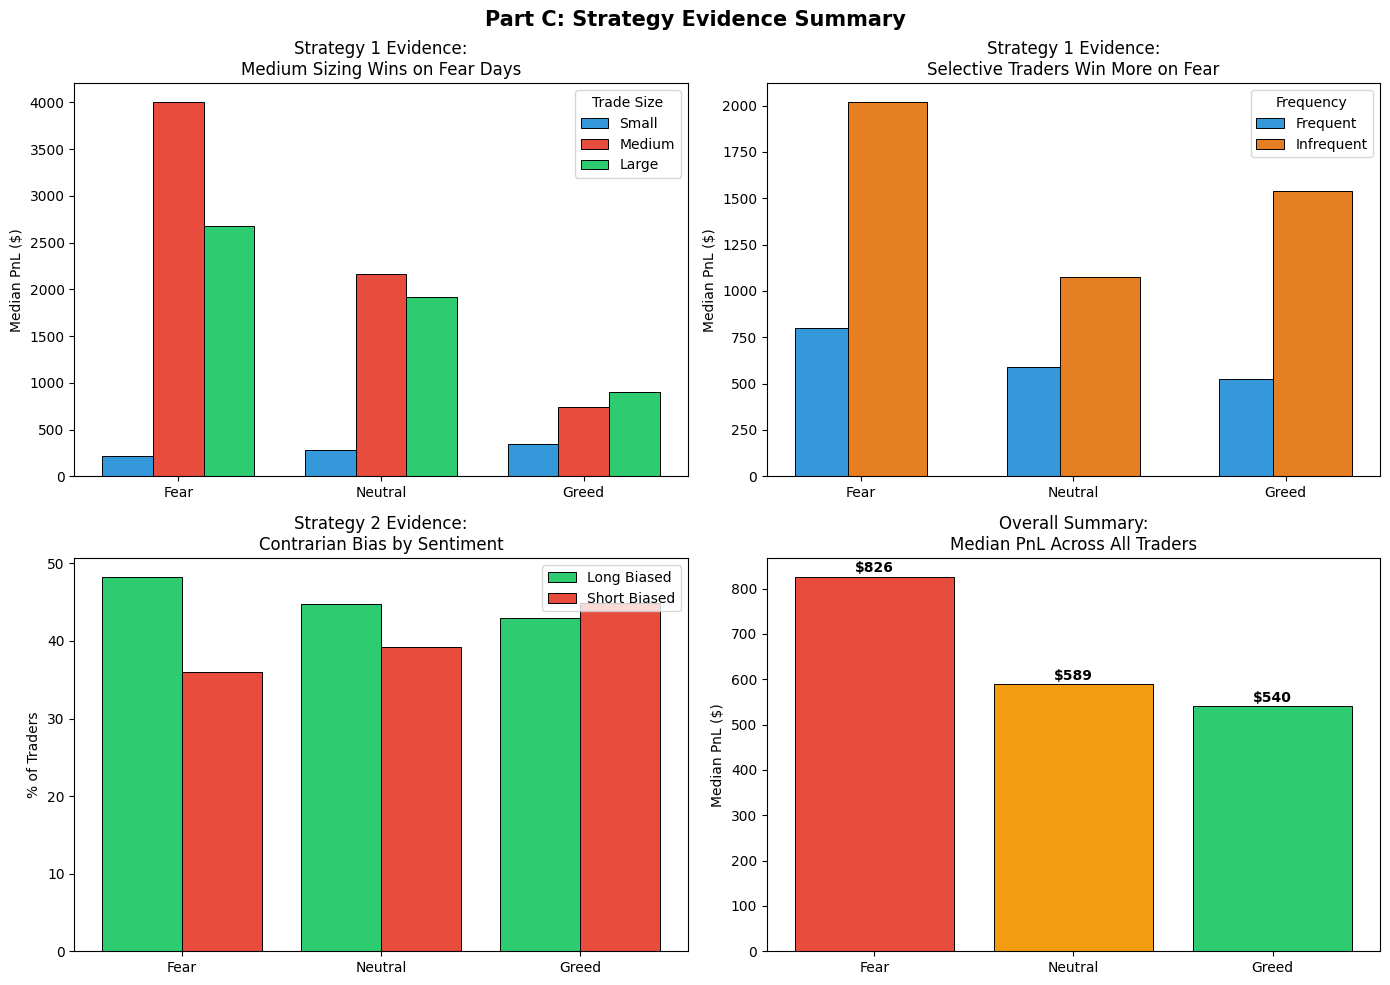

✅ 05_strategy_evidence.png saved

Strategy 1 — Fear is Opportunity
  Trigger : Fear / Extreme Fear days
  Action  : Go long-biased, medium position sizes ($1,710-$4,856)
  Style   : Selective — fewer, higher quality trades
  Evidence: Median PnL 53% higher on Fear ($826 vs $540)
            Medium traders earn $4,005 on Fear vs $739 on Greed

Strategy 2 — Greed: Reduce & Fade
  Trigger : Greed / Extreme Greed days
  Action  : Reduce size, go short-biased or neutral
  Style   : Don't chase momentum
  Evidence: Lowest median PnL on Greed ($540)
            44.9% of traders already short-biased on Greed days



In [17]:
 # PART C — ACTIONABLE STRATEGY VISUALIZATION

# strategy evidence charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Part C: Strategy Evidence Summary', fontsize=15, fontweight='bold')

sentiment_order = ['Fear', 'Neutral', 'Greed']
x = np.arange(len(sentiment_order))
width = 0.25

# medium sizing wins on Fear
seg3_pnl = merged.groupby(['size_segment','sentiment'])['daily_pnl']\
                  .median().unstack().reindex(columns=sentiment_order)
for i, (seg, color) in enumerate(zip(['Small','Medium','Large'],
                                      ['#3498db','#e74c3c','#2ecc71'])):
    axes[0][0].bar(x + i*width, seg3_pnl.loc[seg], width,
                   label=seg, color=color, edgecolor='black', linewidth=0.7)
axes[0][0].set_xticks(x + width)
axes[0][0].set_xticklabels(sentiment_order)
axes[0][0].set_title('Strategy 1 Evidence:\nMedium Sizing Wins on Fear Days')
axes[0][0].set_ylabel('Median PnL ($)')
axes[0][0].legend(title='Trade Size')
axes[0][0].axhline(0, color='black', linewidth=0.5)

# selective trading wins on Fear
seg1_pnl = merged.groupby(['freq_segment','sentiment'])['daily_pnl']\
                  .median().unstack().reindex(columns=sentiment_order)
for i, (seg, color) in enumerate(zip(['Frequent','Infrequent'],
                                      ['#3498db','#e67e22'])):
    axes[0][1].bar(x + i*width, seg1_pnl.loc[seg], width*1.5,
                   label=seg, color=color, edgecolor='black', linewidth=0.7)
axes[0][1].set_xticks(x + width/2)
axes[0][1].set_xticklabels(sentiment_order)
axes[0][1].set_title('Strategy 1 Evidence:\nSelective Traders Win More on Fear')
axes[0][1].set_ylabel('Median PnL ($)')
axes[0][1].legend(title='Frequency')
axes[0][1].axhline(0, color='black', linewidth=0.5)

# contrarian bias by sentiment
bias_data = merged.groupby('sentiment').agg(
    pct_long  = ('long_short_ratio', lambda x: (x > 1).mean() * 100),
    pct_short = ('long_short_ratio', lambda x: (x < 1).mean() * 100)
).reindex(sentiment_order)
x2 = np.arange(len(sentiment_order))
axes[1][0].bar(x2 - 0.2, bias_data['pct_long'],  0.4,
               label='Long Biased',  color='#2ecc71', edgecolor='black', linewidth=0.7)
axes[1][0].bar(x2 + 0.2, bias_data['pct_short'], 0.4,
               label='Short Biased', color='#e74c3c', edgecolor='black', linewidth=0.7)
axes[1][0].set_xticks(x2)
axes[1][0].set_xticklabels(sentiment_order)
axes[1][0].set_title('Strategy 2 Evidence:\nContrarian Bias by Sentiment')
axes[1][0].set_ylabel('% of Traders')
axes[1][0].legend()

# overall PnL summary
overall = merged.groupby('sentiment')['daily_pnl'].median().reindex(sentiment_order)
bars = axes[1][1].bar(sentiment_order, overall,
                       color=['#e74c3c','#f39c12','#2ecc71'],
                       edgecolor='black', linewidth=0.7)
axes[1][1].set_title('Overall Summary:\nMedian PnL Across All Traders')
axes[1][1].set_ylabel('Median PnL ($)')
for bar, val in zip(bars, overall):
    axes[1][1].text(bar.get_x() + bar.get_width()/2,
                    val + 10, f'${val:.0f}', ha='center', fontweight='bold')
axes[1][1].axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('../charts/05_strategy_evidence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 05_strategy_evidence.png saved")

# strategy summary
print("""
Strategy 1 — Fear is Opportunity
  Trigger : Fear / Extreme Fear days
  Action  : Go long-biased, medium position sizes ($1,710-$4,856)
  Style   : Selective — fewer, higher quality trades
  Evidence: Median PnL 53% higher on Fear ($826 vs $540)
            Medium traders earn $4,005 on Fear vs $739 on Greed

Strategy 2 — Greed: Reduce & Fade
  Trigger : Greed / Extreme Greed days
  Action  : Reduce size, go short-biased or neutral
  Style   : Don't chase momentum
  Evidence: Lowest median PnL on Greed ($540)
            44.9% of traders already short-biased on Greed days
""")

## Analysis Summary

### Methodology

Two datasets: Bitcoin Fear/Greed index (daily) and Hyperliquid trades
(211,224 records). Overlap: May 2023–May 2025.

Kept only core trade directions, closed trades with realized PnL (84,626
trades across 32 traders). Built daily per-trader metrics — PnL, win rate,
trade size, long/short ratio — then joined with sentiment.

Split sentiment into 3 buckets (Fear/Neutral/Greed) and segmented traders
three ways: how often they trade, how consistently they profit, and how
big their positions are. No leverage column in the data — used trade size
as a stand-in.

---

### Insights

**1. Fear days are more profitable — consistently**
Traders made 53% more on Fear days ($826 median) than Greed days ($540).
Win rate was also higher (87% vs 84%). Counterintuitive, but the pattern
holds across almost every segment. Market panic seems to create cleaner
entry points for the traders in this dataset.

**2. Traders fade the market, not follow it**
On Fear days they go smaller and longer. On Greed days they size up and
go short. Nobody here is momentum trading — they're doing the opposite
of what the sentiment suggests, and it's working.

**3. Size matters more than frequency on Fear days**
Medium-sized traders ($1,710–$4,856 per trade) made $4,005 on Fear days
vs $739 on Greed — a 5.4x gap. Infrequent traders also outperformed
($2,020 vs $1,539 on Greed). Fewer, better-sized trades beat high
frequency on the days that matter most.

---

### Strategy Recommendations

**Strategy 1 — Fear days: go long, size medium, be selective**
When sentiment hits Fear or Extreme Fear, the data says go contrarian —
long bias, medium position sizes, don't overtrade. Every segment shows
a PnL premium on these days. This is where the edge is.

**Strategy 2 — Greed days: pull back and fade**
Greed days have the worst median PnL. Reduce size, lean short or neutral,
don't chase the move. The traders already doing well on these days are
the ones fading the rally, not following it.

> Note: Only 32 traders in the dataset — patterns are clear but the sample
> is small. No leverage data was available for direct analysis.